In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tomsalm/rossmann-milestone-4/rossmann_processado (1).csv


In [2]:
import os
os.makedirs("/kaggle/working/figures", exist_ok=True)

# Milestone 4 (Notebook 3.0 - Interpretação do Modelo)

Este notebook foca-se na interpretação do modelo final desenvolvido na fase de modelação (notebook 2.0). Para isso, carrega o conjunto de dados já processado, reconstrói o modelo final com os hiperparâmetros otimizados e analisa o seu comportamento através da análise de resíduos e da importância das variáveis. O objetivo não é voltar a treinar ou comparar modelos, mas sim compreender como o modelo escolhido toma as suas decisões e onde residem as suas limitações.

In [3]:
# Bibliotecas usadas na interpretação do modelo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [4]:
# Carregar o dataset processado na fase de exploração (Milestone 2)
caminho = "/kaggle/input/datasets/tomsalm/rossmann-milestone-4/rossmann_processado (1).csv"
df = pd.read_csv(caminho)

# Converter as colunas do One-Hot Encoding para inteiros (0 e 1)
colunas_bool = df.select_dtypes(include="bool").columns
df[colunas_bool] = df[colunas_bool].astype(int)

# Filtrar apenas os dias de loja aberta (dias fechados têm vendas iguais a zero)
df = df[df["Sales"] > 0].copy()

# Transformação logarítmica da variável alvo, para reduzir a assimetria das vendas
df["Sales_log"] = np.log1p(df["Sales"])

print("Dimensão do dataset após preparação:", df.shape)

Dimensão do dataset após preparação: (844338, 25)


In [5]:
# Divisão temporal: os 80% de registos mais antigos para treino, os 20% mais recentes para teste
# Mantém a coerência com a fase de modelação e evita fuga de informação
df = df.sort_values(by=["Ano", "SemanaDoAno"]).reset_index(drop=True)

ponto_corte = int(len(df) * 0.80)
treino = df.iloc[:ponto_corte]
teste = df.iloc[ponto_corte:]

# Separar variáveis preditoras (X) do alvo (y)
colunas_excluir = ["Sales", "Sales_log", "Store"]
X_treino = treino.drop(columns=colunas_excluir)
y_treino = treino["Sales_log"]
X_teste = teste.drop(columns=colunas_excluir)
y_teste = teste["Sales_log"]

print("Registos de treino:", X_treino.shape[0])
print("Registos de teste:", X_teste.shape[0])

Registos de treino: 675470
Registos de teste: 168868


In [6]:
# Treinar o modelo final com os hiperparâmetros otimizados na fase de modelação (notebook 2.0)
# A pesquisa de hiperparâmetros não é repetida aqui, pois os melhores valores já são conhecidos
modelo_final = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.2,
    subsample=1.0,
    random_state=42,
    n_jobs=-1
)
modelo_final.fit(X_treino, y_treino)

# Prever no conjunto de teste
previsoes_final_teste = modelo_final.predict(X_teste)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## Análise de Resíduos

Um resíduo é a diferença entre o valor real das vendas e o valor previsto pelo modelo. A análise dos resíduos permite perceber onde e como o modelo erra, revelando padrões que ajudam a compreender as suas limitações.

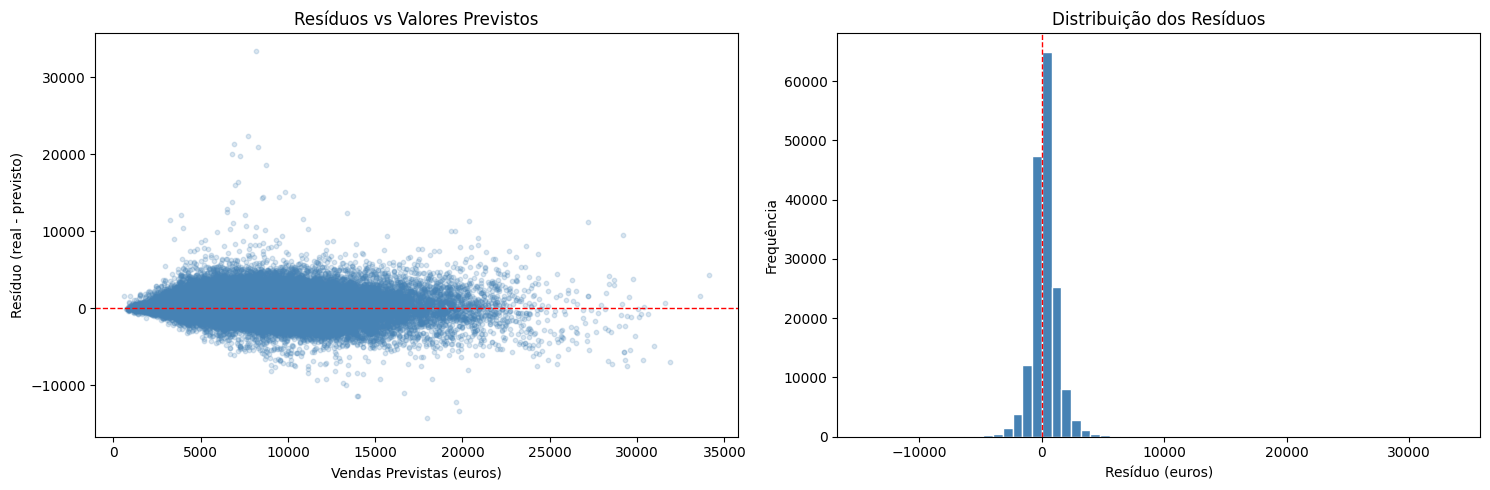

Resíduo médio: 257.94 euros
Desvio padrão dos resíduos: 1083.05 euros


In [7]:
# Reverter as previsões e os valores reais do teste para a escala original (euros)
previsoes_euros = np.expm1(previsoes_final_teste)
reais_euros = np.expm1(y_teste)

# Calcular os resíduos (erro = valor real menos valor previsto)
residuos = reais_euros - previsoes_euros

# Gráfico de resíduos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(previsoes_euros, residuos, alpha=0.2, s=10, color="steelblue")
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Resíduos vs Valores Previstos")
axes[0].set_xlabel("Vendas Previstas (euros)")
axes[0].set_ylabel("Resíduo (real - previsto)")

axes[1].hist(residuos, bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduo (euros)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.savefig("/kaggle/working/figures/analise_residuos.png", dpi=150, bbox_inches="tight")
plt.show()

print("Resíduo médio:", round(residuos.mean(), 2), "euros")
print("Desvio padrão dos resíduos:", round(residuos.std(), 2), "euros")

### Leitura do Gráfico de Resíduos

O gráfico da esquerda mostra os resíduos em função das vendas previstas. Os pontos concentram-se em torno da linha zero, o que indica que o modelo acerta na maioria das previsões. No entanto, a dispersão aumenta à medida que as vendas previstas crescem, formando um padrão em funil. Isto significa que o modelo é mais preciso nas lojas de vendas baixas e médias e tende a errar mais, em valor absoluto, nas lojas de vendas elevadas.

O gráfico da direita mostra a distribuição dos resíduos, com uma forma aproximadamente simétrica e centrada perto do zero. O resíduo médio é ligeiramente positivo (cerca de 258 euros), o que indica que o modelo tende a subestimar muito ligeiramente as vendas reais. Este desvio é pequeno face ao valor médio das vendas e não compromete a utilidade do modelo.

In [8]:
# Analisar as características das piores previsões (os 5% com maior erro percentual)
analise = X_teste.copy()
analise["venda_real"] = reais_euros.values
analise["venda_prevista"] = previsoes_euros
analise["erro_absoluto"] = np.abs(residuos.values)
analise["erro_percentual"] = np.abs(residuos.values / reais_euros.values) * 100

limite_erro = analise["erro_percentual"].quantile(0.95)
piores = analise[analise["erro_percentual"] > limite_erro]

print("Características das piores previsões (5% com maior erro):")
print(f"Erro percentual médio nas piores: {piores['erro_percentual'].mean():.1f}%")
print(f"\nVenda real média nas piores: {piores['venda_real'].mean():.0f} euros")
print(f"Venda real média no geral: {analise['venda_real'].mean():.0f} euros")
print(f"\nFim de semana nas piores: {piores['FimDeSemana'].mean()*100:.0f}% dos casos")
print(f"Fim de semana no geral: {analise['FimDeSemana'].mean()*100:.0f}% dos casos")

Características das piores previsões (5% com maior erro):
Erro percentual médio nas piores: 41.4%

Venda real média nas piores: 6935 euros
Venda real média no geral: 7128 euros

Fim de semana nas piores: 24% dos casos
Fim de semana no geral: 17% dos casos


### Onde o Modelo Mais Falha

Ao isolar os 5% de previsões com maior erro percentual, com um erro médio de cerca de 41%, identifica-se um padrão claro: os dias de fim de semana estão sobre-representados nas piores previsões, correspondendo a cerca de 24% dos casos, contra 17% no conjunto geral. 

Este resultado é coerente com a análise exploratória da fase anterior, que já tinha mostrado um comportamento mais irregular das vendas ao fim de semana, sobretudo ao domingo, devido ao encerramento de muitas lojas. O modelo tem, assim, mais dificuldade em prever as vendas nestes dias atípicos, o que constitui uma das suas principais limitações.

## Importância das Variáveis

O XGBoost permite medir quanto cada variável contribuiu para as previsões do modelo, respondendo às perguntas de investigação sobre quais os fatores que mais influenciam as vendas.

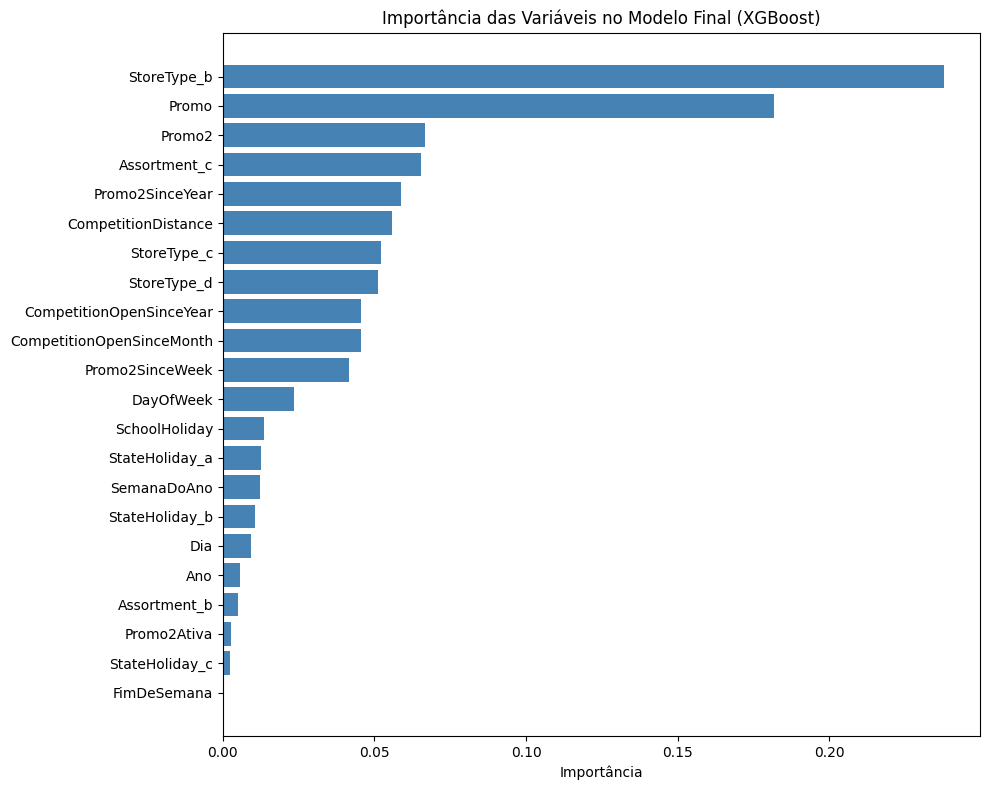

Importância das variáveis (ordenada):
                 variavel  importancia
              StoreType_b     0.237762
                    Promo     0.181741
                   Promo2     0.066681
             Assortment_c     0.065473
          Promo2SinceYear     0.058854
      CompetitionDistance     0.055640
              StoreType_c     0.052222
              StoreType_d     0.051128
 CompetitionOpenSinceYear     0.045655
CompetitionOpenSinceMonth     0.045416
          Promo2SinceWeek     0.041455
                DayOfWeek     0.023510
            SchoolHoliday     0.013670
           StateHoliday_a     0.012732
              SemanaDoAno     0.012280
           StateHoliday_b     0.010731
                      Dia     0.009334
                      Ano     0.005637
             Assortment_b     0.004927
              Promo2Ativa     0.002790
           StateHoliday_c     0.002363
              FimDeSemana     0.000000


In [9]:
# Extrair e ordenar a importância de cada variável
importancias = pd.DataFrame({
    "variavel": X_treino.columns,
    "importancia": modelo_final.feature_importances_
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importancias["variavel"], importancias["importancia"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis no Modelo Final (XGBoost)")
plt.xlabel("Importância")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/importancia_variaveis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Importância das variáveis (ordenada):")
print(importancias.to_string(index=False))

### Leitura da Importância das Variáveis

A variável mais influente é, com larga vantagem, o tipo de loja "b" (*StoreType_b*), com uma importância de cerca de 0,24. Este resultado confirma o padrão identificado na exploração, em que o tipo de loja "b", apesar de ser o menos frequente, era o que apresentava vendas medianas mais elevadas. Em segundo lugar surge a promoção (*Promo*), confirmando o forte efeito das campanhas promocionais. No conjunto, são sobretudo o perfil da loja e as promoções que determinam o volume de vendas.

Destaca-se ainda que a variável *FimDeSemana* apresentou uma importância praticamente nula. Isto não significa que o fim de semana não afete as vendas, mas sim que essa informação já está contida na variável *DayOfWeek*, mais detalhada. Sendo a *FimDeSemana* derivada desta, o modelo optou por usar a variável original, tornando a criada redundante. Este é um resultado válido, pois mostra que nem todas as variáveis criadas se revelaram úteis.

## Síntese da Interpretação

A análise do modelo final permitiu compreender o seu comportamento. A análise de resíduos mostrou que o modelo é mais preciso nas vendas baixas e médias e tem maior dificuldade nas vendas elevadas e nos dias de fim de semana, o que é coerente com os padrões identificados na fase de exploração. A importância das variáveis confirmou que o tipo de loja e as promoções são os fatores mais determinantes nas vendas, respondendo às perguntas de investigação sobre quais os fatores que mais influenciam e mais contribuem para a previsão. Esta interpretação serve de base à discussão de resultados e às conclusões da fase final do projeto.